# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


Informasi Dataset:
Nama Dataset: Predict Students Dropout and Academic Success
Sumber: UCI Machine Learning Repository
Tautan: https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success
Deskripsi: Dataset ini berisi 4.424 data mahasiswa dari institusi pendidikan tinggi. Dataset ini digunakan untuk memprediksi apakah mahasiswa akan lulus (Graduate) atau putus sekolah (Dropout).
Karakteristik Data: Multivariate (Tabular)
Jumlah Fitur: 36 Fitur (Demografi, Sosial-Ekonomi, dan Akademik)
Target: Kolom `Target` (Dropout, Enrolled, Graduate) - 'Enrolled' didrop pada tahap preprocessing.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import zipfile
import os

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Mengatur tampilan visual seaborn
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [7]:
# Mengunduh dataset UCI ML Repository
url = "https://archive.ics.uci.edu/static/public/697/predict+students+dropout+and+academic+success.zip"
file_name = "students_dropout.zip"

print("Mengunduh dataset...")
urllib.request.urlretrieve(url, file_name)

# Ekstrak file zip
print("Mengekstrak dataset...")
with zipfile.ZipFile(file_name, 'r') as zip_ref:
    zip_ref.extractall("dataset_raw")

# Load ke dalam Pandas DataFrame
csv_path = "dataset_raw/data.csv"
df = pd.read_csv(csv_path, sep=';')

print("Data Loading Selesai!")
print(f"Dimensi dataset awal: {df.shape}")
df.head()

Mengunduh dataset...
Mengekstrak dataset...
Data Loading Selesai!
Dimensi dataset awal: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

 INFO DATASET 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification    

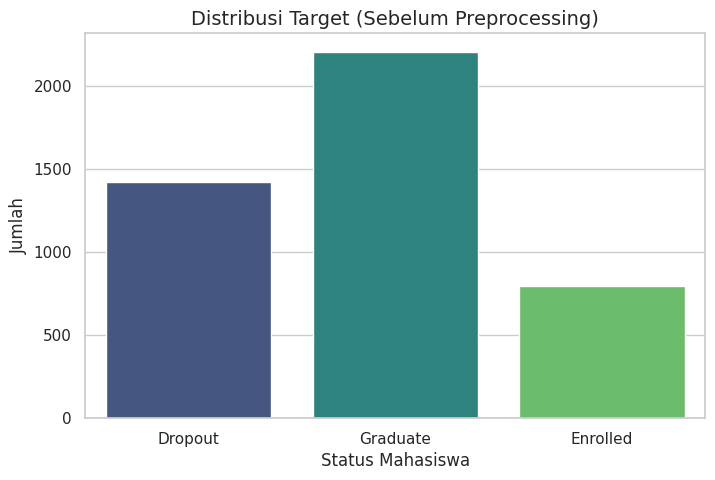

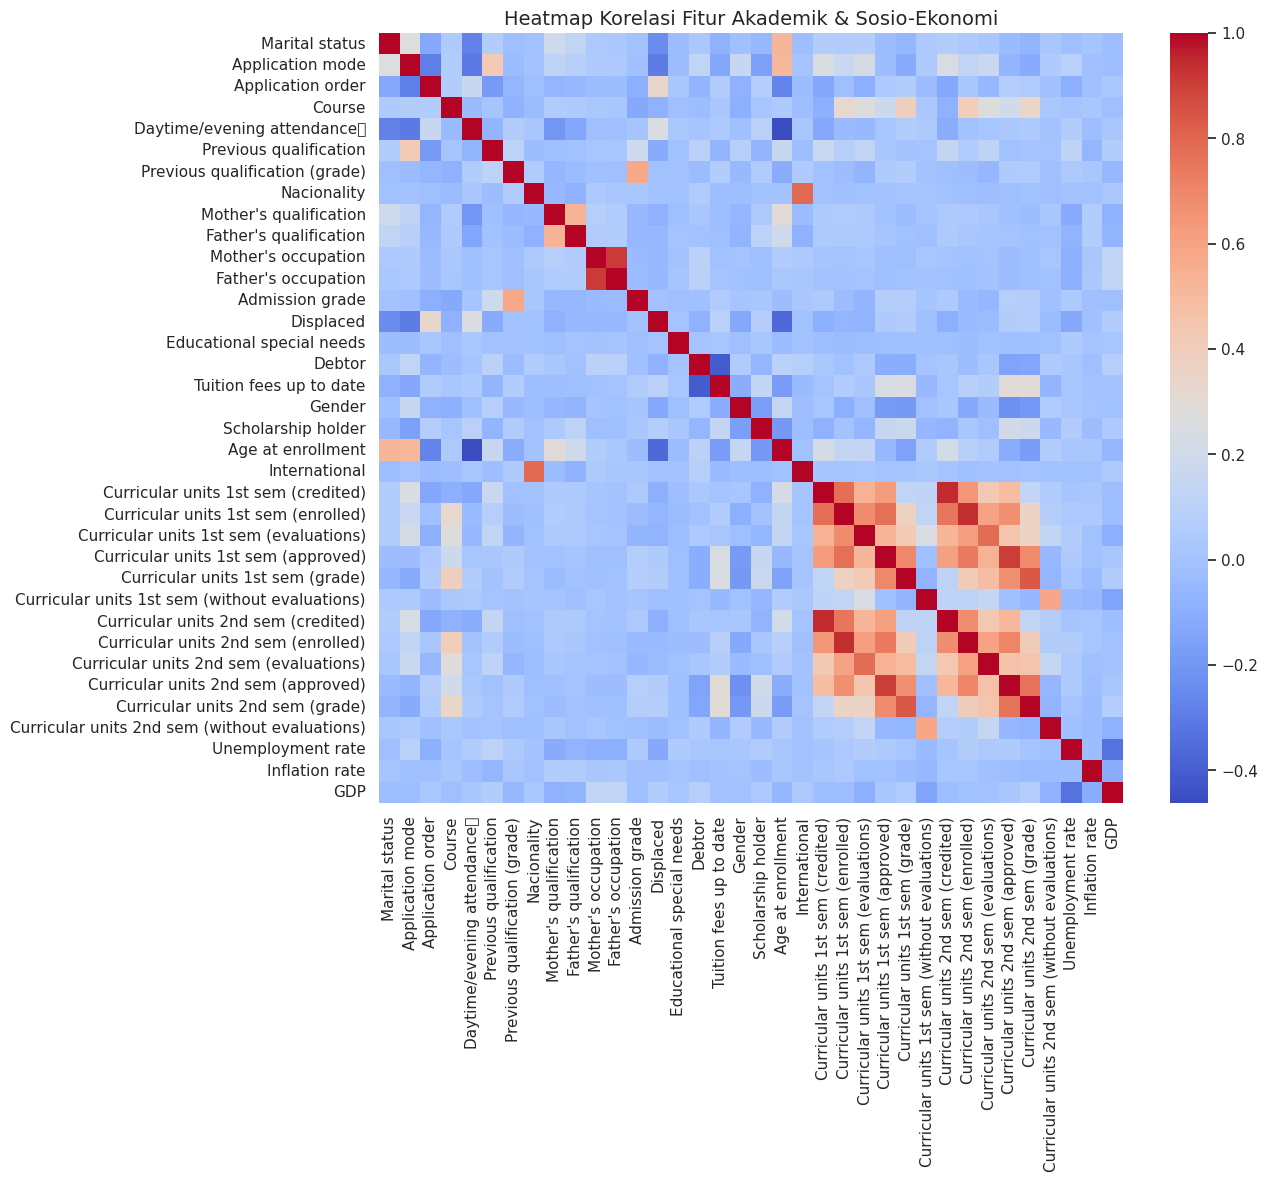

In [8]:
# Cek informasi dasar dan Missing Values
print(" INFO DATASET ")
df.info()

print("\n CEK MISSING VALUES ")
print(df.isnull().sum().sum(), "Missing Values Ditemukan")

# Visualisasi Distribusi Kelas Target
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Target', palette='viridis')
plt.title('Distribusi Target (Sebelum Preprocessing)', fontsize=14)
plt.xlabel('Status Mahasiswa')
plt.ylabel('Jumlah')
plt.show()

# Analisis Korelasi
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False, fmt='.2f')
plt.title('Heatmap Korelasi Fitur Akademik & Sosio-Ekonomi', fontsize=14)
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [9]:
df_clean = df.copy()

# Filter Kelas
df_clean = df_clean[df_clean['Target'] != 'Enrolled']

# Label Encoding untuk Target
le = LabelEncoder()
df_clean['Target'] = le.fit_transform(df_clean['Target'])

# Pemisahan Fitur dan Target
X = df_clean.drop('Target', axis=1)
y = df_clean['Target']

# Standardisasi/Scaling Fitur Numerik
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Menggabungkan kembali data yang sudah bersih dan diskalakan
df_final = X_scaled.copy()
df_final['Target'] = y.values

print(f"Dimensi dataset setelah preprocessing: {df_final.shape}")
print("\nContoh data yang sudah siap latih:")
display(df_final.head())

# Menyimpan dataset bersih untuk digunakan di Kriteria 2
os.makedirs("preprocessing", exist_ok=True)
df_final.to_csv("preprocessing/data_siap_latih.csv", index=False)
print("\n[SUCCESS] Data bersih berhasil disimpan di folder 'preprocessing/data_siap_latih.csv'")

Dimensi dataset setelah preprocessing: (3630, 37)

Contoh data yang sudah siap latih:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,-0.300686,-0.081917,2.436822,-4.197769,0.355850,-0.352421,-0.825034,-0.124214,-0.063288,-0.692162,...,-0.287686,-2.782691,-1.958586,-1.429014,-1.831085,-0.190148,-0.311312,0.121615,0.774119,0
1,-0.300686,-0.197149,-0.562471,0.193388,0.355850,-0.352421,2.045805,-0.124214,-1.218383,-1.281423,...,-0.287686,-0.131002,-0.444817,0.468555,0.662383,-0.190148,0.850919,-1.106070,0.353704,1
2,-0.300686,-1.003777,2.436822,0.104434,0.355850,-0.352421,-0.825034,-0.124214,1.091807,0.944677,...,-0.287686,-0.131002,-1.958586,-1.429014,-1.831085,-0.190148,-0.311312,0.121615,0.774119,0
3,-0.300686,-0.081917,0.187353,0.444298,0.355850,-0.352421,-0.825034,-0.124214,1.155979,0.944677,...,-0.287686,-0.131002,0.564362,0.152293,0.431281,-0.190148,-0.836191,-1.467154,-1.376634,1
4,1.330837,1.185642,-0.562471,-0.406087,-2.810171,-0.352421,-2.487099,-0.124214,1.091807,1.010150,...,-0.287686,-0.131002,-0.444817,0.468555,0.540750,-0.190148,0.850919,-1.106070,0.353704,1



[SUCCESS] Data bersih berhasil disimpan di folder 'preprocessing/data_siap_latih.csv'
